# Estimativa de $t_c$ e colapso de escala — versão refinada

Mudanças em relação à versão original:

1. `estimate_tc_by_max_slope` usa **Savitzky–Golay** com janela adaptativa em $N$ e recorte de borda.
2. Novo `fit_tc_with_offset`: ajuste não-linear $t_c(N)=t_\infty + a\,N^{-\theta}$.
3. Separação clara entre `theta_tc` (scaling de $t_c$) e `theta_collapse` (expoente do colapso).
4. `collapse_score_physical` com `pmin/pmax` consistentes e descarte opcional da pior curva.
5. Substituído `plt.cm.get_cmap` (depreciado) por `plt.get_cmap`.
6. Novo `fit_power_law_times_log`: ajuste com correção logarítmica $t_c(N)\sim N^{\theta}\log N$.
7. Comparação automática entre $N^{\theta}$ e $N^{\theta}\log N$ usando $R^2$ (impressa no diagnóstico).

In [26]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit

mpl.rcParams["text.usetex"] = False

## Leitura e limpeza

In [27]:
def load_csv_attack(N, C, mode="random"):
    fname = f"./data_random_medias_random/{mode}_{N}_{C}.csv"
    if not os.path.exists(fname):
        print(f"[AVISO] Arquivo não encontrado: {fname}")
        return pd.DataFrame()
    df = pd.read_csv(fname, sep=",", header=0)
    return df.drop(columns=["node1", "node2"], errors="ignore")


def clean_tp(df):
    if df.empty or ("t" not in df.columns) or ("p" not in df.columns):
        return np.array([]), np.array([])

    t = np.asarray(df["t"], float)
    p = np.asarray(df["p"], float)

    mask = np.isfinite(t) & np.isfinite(p) & (t > 0)
    t, p = t[mask], p[mask]

    if len(t) == 0:
        return t, p

    idx = np.argsort(t)
    return t[idx], p[idx]

## Estimadores de $t_c(N)$ e $t_{\max}(N)$

Definição: $t_c(N) = \arg\max_t \dfrac{dp}{d\ln t}$, com a derivada suavizada por Savitzky–Golay (preserva a posição do pico melhor que média móvel).

In [28]:
def _sg_window(n_points, frac=0.05, wmin=7, wmax=51):
    w = int(max(wmin, min(wmax, frac * n_points)))
    if w % 2 == 0:
        w += 1
    return w


def estimate_tc_by_max_slope(df, edge_frac=0.05):
    t, p = clean_tp(df)
    n = len(t)
    if n < 25:
        return np.nan

    logt = np.log(t)
    dp_dlogt = np.gradient(p, logt)

    window = _sg_window(n, frac=0.05, wmin=7, wmax=51)
    if window < n:
        try:
            dp_dlogt = savgol_filter(dp_dlogt, window, polyorder=3)
        except ValueError:
            pass

    k = max(2, int(edge_frac * n))
    interior = slice(k, n - k)

    i_local = int(np.argmax(dp_dlogt[interior]))
    return float(t[interior][i_local])


def estimate_tmax(df):
    t, _ = clean_tp(df)
    if len(t) == 0:
        return np.nan
    return float(np.max(t))

## Ajustes: lei de potência log-log, com correção log e com offset

- Log-log puro: $y = A\,N^\alpha$.
- Correção logarítmica: $t_c(N) = A\,N^\theta\log N$.
- Com offset: $t_c(N) = t_\infty + a\,N^{-\theta}$. Se $t_\infty$ for compatível com zero, o ajuste log-log puro é justificado.

In [29]:
def fit_power_law(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x, y = x[mask], y[mask]

    if len(x) < 2:
        return np.nan, np.nan, np.nan

    logx, logy = np.log(x), np.log(y)
    alpha, intercept = np.polyfit(logx, logy, 1)
    logy_hat = alpha * logx + intercept

    ss_res = np.sum((logy - logy_hat) ** 2)
    ss_tot = np.sum((logy - np.mean(logy)) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return alpha, intercept, r2


def fit_power_law_with_error(x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x, y = x[mask], y[mask]

    if len(x) < 3:
        theta, b, r2 = fit_power_law(x, y)
        return theta, np.nan, b, r2

    logx, logy = np.log(x), np.log(y)
    coeffs, cov = np.polyfit(logx, logy, 1, cov=True)
    theta, intercept = coeffs
    theta_err = np.sqrt(cov[0, 0]) if np.isfinite(cov[0, 0]) else np.nan

    logy_hat = theta * logx + intercept
    ss_res = np.sum((logy - logy_hat) ** 2)
    ss_tot = np.sum((logy - np.mean(logy)) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return float(theta), float(theta_err), float(intercept), float(r2)


def fit_power_law_times_log(x, y, log_power=1.0):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 1.0) & (y > 0)
    x, y = x[mask], y[mask]

    if len(x) < 2:
        return np.nan, np.nan, np.nan

    logx = np.log(x)
    loglogx = np.log(logx)
    logy = np.log(y)

    # Ajuste linear de log(y/log(N)^k) = intercept + theta*log(N)
    y_reduced = logy - log_power * loglogx
    theta, intercept = np.polyfit(logx, y_reduced, 1)
    logy_hat = intercept + theta * logx + log_power * loglogx

    ss_res = np.sum((logy - logy_hat) ** 2)
    ss_tot = np.sum((logy - np.mean(logy)) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return theta, intercept, r2


def fit_power_law_times_log_with_error(x, y, log_power=1.0):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 1.0) & (y > 0)
    x, y = x[mask], y[mask]

    if len(x) < 3:
        theta, b, r2 = fit_power_law_times_log(x, y, log_power=log_power)
        return theta, np.nan, b, r2

    logx = np.log(x)
    loglogx = np.log(logx)
    logy = np.log(y)
    y_reduced = logy - log_power * loglogx

    coeffs, cov = np.polyfit(logx, y_reduced, 1, cov=True)
    theta, intercept = coeffs
    theta_err = np.sqrt(cov[0, 0]) if np.isfinite(cov[0, 0]) else np.nan

    logy_hat = intercept + theta * logx + log_power * loglogx
    ss_res = np.sum((logy - logy_hat) ** 2)
    ss_tot = np.sum((logy - np.mean(logy)) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return float(theta), float(theta_err), float(intercept), float(r2)


def fit_tc_with_offset(Ns, tcs):
    Ns = np.asarray(Ns, float)
    tcs = np.asarray(tcs, float)
    mask = np.isfinite(Ns) & np.isfinite(tcs) & (Ns > 0)
    Ns, tcs = Ns[mask], tcs[mask]

    if len(Ns) < 4:
        return None

    def model(N, t_inf, a, theta):
        return t_inf + a * N ** (-theta)

    alpha, intercept, _ = fit_power_law(Ns, tcs)
    p0 = [
        float(np.min(tcs)) * 0.5,
        float(np.exp(intercept)) if np.isfinite(intercept) else 1.0,
        float(-alpha) if np.isfinite(alpha) else 0.5,
    ]
    try:
        popt, _ = curve_fit(model, Ns, tcs, p0=p0, maxfev=20000)
        residuals = tcs - model(Ns, *popt)
        ss_res = np.sum(residuals ** 2)
        ss_tot = np.sum((tcs - np.mean(tcs)) ** 2)
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
        return {"t_inf": popt[0], "a": popt[1], "theta": popt[2], "r2": r2}
    except (RuntimeError, ValueError):
        return None


def estimate_article_exponents(Ns, tcs_dict, tmaxs_dict, c_inf_label=r"$C=N$"):
    results = {}
    for label in tcs_dict:
        tcs = tcs_dict[label]
        tmaxs = tmaxs_dict[label]

        if label == c_inf_label:
            theta_minus, theta_minus_err, _, r2_tc = fit_power_law_with_error(Ns, tcs)
            theta_plus, theta_plus_err, _, r2_tmax = fit_power_law_times_log_with_error(
                Ns, tmaxs, log_power=1.0
            )
            results[label] = {
                "theta_minus": theta_minus,
                "theta_minus_err": theta_minus_err,
                "theta_plus": theta_plus,
                "theta_plus_err": theta_plus_err,
                "r2_tc": r2_tc,
                "r2_tmax": r2_tmax,
            }
        else:
            theta_tc, theta_tc_err, _, r2_tc = fit_power_law_with_error(Ns, tcs)
            theta_tmax, theta_tmax_err, _, r2_tmax = fit_power_law_times_log_with_error(
                Ns, tmaxs, log_power=1.0
            )
            results[label] = {
                "theta_tc": theta_tc,
                "theta_tc_err": theta_tc_err,
                "theta_tmax": theta_tmax,
                "theta_tmax_err": theta_tmax_err,
                "r2_tc": r2_tc,
                "r2_tmax": r2_tmax,
            }
    return results

## Score de colapso e estimativa de $\theta_{\text{collapse}}$

Minimiza a variância vertical das curvas $p$ vs $(t - t_c)\,N^{-\theta}$, ponderada por $|d\bar p/dx|$ para enfatizar a janela crítica. Descarta opcionalmente a curva mais discordante.

In [30]:
def collapse_score_physical(
    dfs, Ns, tcs, theta,
    masks=None, pmin=0.05, pmax=0.9, ngrid=400,
    drop_worst=True,
):
    curves = []
    for i, (df, N, tc) in enumerate(zip(dfs, Ns, tcs)):
        t, p = clean_tp(df)
        if len(t) == 0 or not np.isfinite(tc):
            continue
        m = masks[i] if masks is not None else ((p >= pmin) & (p <= pmax))
        if np.sum(m) < 10:
            continue
        t, p = t[m], p[m]
        x = (t - tc) * (N ** (-theta))
        idx = np.argsort(x)
        curves.append((x[idx], p[idx]))

    if len(curves) < 2:
        return np.inf

    left = max(c[0][0] for c in curves)
    right = min(c[0][-1] for c in curves)
    if not left < right:
        return np.inf

    grid = np.linspace(left, right, ngrid)
    P = np.vstack([np.interp(grid, x, p) for x, p in curves])

    mean_curve = np.mean(P, axis=0)
    dPdx = np.gradient(mean_curve, grid)
    weight = np.abs(dPdx) + 1e-7

    if drop_worst and P.shape[0] >= 4:
        dev = np.average((P - mean_curve) ** 2, axis=1, weights=weight)
        keep = np.ones(P.shape[0], dtype=bool)
        keep[int(np.argmax(dev))] = False
        P = P[keep]
        mean_curve = np.mean(P, axis=0)

    score = np.average(np.var(P, axis=0), weights=weight)
    return float(score)


def estimate_theta_by_collapse(
    dfs, Ns, tcs,
    masks=None, theta_min=0.0, theta_max=6.0,
    coarse_points=300, refine_points=300,
    pmin=0.05, pmax=0.9,
):
    def score(theta):
        return collapse_score_physical(
            dfs, Ns, tcs, theta,
            masks=masks, pmin=pmin, pmax=pmax,
        )

    grid1 = np.linspace(theta_min, theta_max, coarse_points)
    scores1 = np.array([score(th) for th in grid1])
    i1 = int(np.argmin(scores1))
    theta1 = float(grid1[i1])

    step = (theta_max - theta_min) / (coarse_points - 1)
    left = max(theta_min, theta1 - 3 * step)
    right = min(theta_max, theta1 + 3 * step)

    grid2 = np.linspace(left, right, refine_points)
    scores2 = np.array([score(th) for th in grid2])
    return float(grid2[int(np.argmin(scores2))])

## Impressões e diagnósticos

In [31]:
def print_tcs(Ns, tcs_dict):
    print("\n==============================")
    print("t_c(N) encontrados")
    print("==============================")
    for label, tcs in tcs_dict.items():
        print(f"\n{label}")
        for N, tc in zip(Ns, tcs):
            print(f"N={int(N):5d} | t_c={tc:.6g}")


def print_scalings(Ns, tcs_dict, tmaxs_dict):
    print("\n==============================")
    print("AJUSTE log-log puro: t_c ~ N^theta")
    print("==============================")
    pure_fit = {}
    for label, tcs in tcs_dict.items():
        theta, b, r2 = fit_power_law(Ns, tcs)
        pure_fit[label] = (theta, b, r2)
        if np.isfinite(theta):
            print(f"{label}: t_c ~ N^{theta:.3f} (R² = {r2:.3f})")
        else:
            print(f"{label}: ajuste falhou")

    print("\n==============================")
    print("AJUSTE COM CORREÇÃO LOG: t_c ~ N^theta log(N)")
    print("==============================")
    log_fit = {}
    for label, tcs in tcs_dict.items():
        theta, b, r2 = fit_power_law_times_log(Ns, tcs, log_power=1.0)
        log_fit[label] = (theta, b, r2)
        if np.isfinite(theta):
            print(f"{label}: t_c ~ N^{theta:.3f} log(N) (R² = {r2:.3f})")
        else:
            print(f"{label}: ajuste falhou")

    print("\nComparação (R² maior favorece o modelo):")
    for label in tcs_dict:
        r2_pure = pure_fit[label][2]
        r2_log = log_fit[label][2]
        if np.isfinite(r2_pure) and np.isfinite(r2_log):
            winner = "N^theta log(N)" if r2_log > r2_pure else "N^theta"
            print(f"{label}: R²_puro={r2_pure:.3f}, R²_log={r2_log:.3f} -> favorece {winner}")
        else:
            print(f"{label}: comparação indisponível")

    print("\n==============================")
    print("AJUSTE COM OFFSET: t_c(N) = t_inf + a N^(-theta)")
    print("==============================")
    for label, tcs in tcs_dict.items():
        fit = fit_tc_with_offset(Ns, tcs)
        if fit is None:
            print(f"{label}: ajuste com offset falhou")
        else:
            print(
                f"{label}: t_inf={fit['t_inf']:.4g}, "
                f"a={fit['a']:.4g}, theta={fit['theta']:.3f}, "
                f"R²={fit['r2']:.3f}"
            )

    print("\n==============================")
    print("AJUSTE t_max(N) ~ N^alpha")
    print("==============================")
    tmax_pure_fit = {}
    for label, tmaxs in tmaxs_dict.items():
        alpha, b, r2 = fit_power_law(Ns, tmaxs)
        tmax_pure_fit[label] = (alpha, b, r2)
        if np.isfinite(alpha):
            print(f"{label}: t_max ~ N^{alpha:.3f} (R² = {r2:.3f})")
        else:
            print(f"{label}: ajuste falhou")

    print("\n==============================")
    print("AJUSTE t_max(N) ~ N^theta log(N)")
    print("==============================")
    tmax_log_fit = {}
    for label, tmaxs in tmaxs_dict.items():
        theta, b, r2 = fit_power_law_times_log(Ns, tmaxs, log_power=1.0)
        tmax_log_fit[label] = (theta, b, r2)
        if np.isfinite(theta):
            print(f"{label}: t_max ~ N^{theta:.3f} log(N) (R² = {r2:.3f})")
        else:
            print(f"{label}: ajuste falhou")

    print("\nComparação t_max (R² maior favorece o modelo):")
    for label in tmaxs_dict:
        r2_pure = tmax_pure_fit[label][2]
        r2_log = tmax_log_fit[label][2]
        if np.isfinite(r2_pure) and np.isfinite(r2_log):
            winner = "N^theta log(N)" if r2_log > r2_pure else "N^alpha"
            print(f"{label}: R²_puro={r2_pure:.3f}, R²_log={r2_log:.3f} -> favorece {winner}")
        else:
            print(f"{label}: comparação indisponível")


def print_article_summary(article_results, c_inf_label=r"$C=N$"):
    print("\n" + "=" * 80)
    print("RESUMO NO FORMATO DO ARTIGO")
    print("=" * 80)
    print("C finito: usar theta de t_c(N) e conferir com theta de t_max(N) ~ N^theta log(N)")
    print("C=N: usar theta_minus de t_c(N) e theta_plus de t_max(N) ~ N^theta log(N)")

    for label, vals in article_results.items():
        print("\n" + "-" * 80)
        print(label)
        print("-" * 80)

        if label == c_inf_label:
            tm = vals["theta_minus"]
            tm_err = vals["theta_minus_err"]
            tp = vals["theta_plus"]
            tp_err = vals["theta_plus_err"]
            r2_tc = vals["r2_tc"]
            r2_tmax = vals["r2_tmax"]

            txt_tm = f"{tm:.3f} ± {tm_err:.3f}" if np.isfinite(tm_err) else f"{tm:.3f}"
            txt_tp = f"{tp:.3f} ± {tp_err:.3f}" if np.isfinite(tp_err) else f"{tp:.3f}"
            print(f"theta_minus (de t_c): {txt_tm} (R²={r2_tc:.3f})")
            print(f"theta_plus  (de t_max/logN): {txt_tp} (R²={r2_tmax:.3f})")
        else:
            tc = vals["theta_tc"]
            tc_err = vals["theta_tc_err"]
            tmax = vals["theta_tmax"]
            tmax_err = vals["theta_tmax_err"]
            r2_tc = vals["r2_tc"]
            r2_tmax = vals["r2_tmax"]

            txt_tc = f"{tc:.3f} ± {tc_err:.3f}" if np.isfinite(tc_err) else f"{tc:.3f}"
            txt_tmax = f"{tmax:.3f} ± {tmax_err:.3f}" if np.isfinite(tmax_err) else f"{tmax:.3f}"
            print(f"theta (de t_c): {txt_tc} (R²={r2_tc:.3f})")
            print(f"theta (de t_max/logN): {txt_tmax} (R²={r2_tmax:.3f})")

## Plots: scaling, razão, diagnóstico e colapso

In [32]:
def plot_scaling_tc_tmax(Ns, C1_dfs, C2_dfs, C3_dfs, CN_dfs):
    tcs_dict = {
        r"$C=1$": np.array([estimate_tc_by_max_slope(df) for df in C1_dfs]),
        r"$C=2$": np.array([estimate_tc_by_max_slope(df) for df in C2_dfs]),
        r"$C=3$": np.array([estimate_tc_by_max_slope(df) for df in C3_dfs]),
        r"$C=N$": np.array([estimate_tc_by_max_slope(df) for df in CN_dfs]),
    }
    tmaxs_dict = {
        r"$C=1$": np.array([estimate_tmax(df) for df in C1_dfs]),
        r"$C=2$": np.array([estimate_tmax(df) for df in C2_dfs]),
        r"$C=3$": np.array([estimate_tmax(df) for df in C3_dfs]),
        r"$C=N$": np.array([estimate_tmax(df) for df in CN_dfs]),
    }

    markers = {r"$C=1$": "s", r"$C=2$": "o", r"$C=3$": "^", r"$C=N$": "D"}
    colors = {r"$C=1$": "black", r"$C=2$": "purple", r"$C=3$": "red", r"$C=N$": "orange"}

    print_tcs(Ns, tcs_dict)
    print_scalings(Ns, tcs_dict, tmaxs_dict)

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    Nfit = np.logspace(np.log10(np.min(Ns)), np.log10(np.max(Ns)), 300)

    for label, tcs in tcs_dict.items():
        theta, b, _ = fit_power_law(Ns, tcs)
        theta_log, b_log, _ = fit_power_law_times_log(Ns, tcs, log_power=1.0)

        ax[0].loglog(Ns, tcs, marker=markers[label], linestyle="None",
                     color=colors[label], label=label)
        if np.isfinite(theta):
            ax[0].loglog(Nfit, np.exp(b) * Nfit ** theta, "--", color=colors[label])
        if np.isfinite(theta_log):
            ax[0].loglog(
                Nfit,
                np.exp(b_log) * Nfit ** theta_log * np.log(Nfit),
":",
                color=colors[label],
            )

    ax[0].set_xlabel(r"$N$")
    ax[0].set_ylabel(r"$t_c(N)$")
    ax[0].set_title(r"(a)")
    legend_lines_a = [
        Line2D([0], [0], color="gray", linestyle="--", label=r"$N^{\theta}$"),
        Line2D([0], [0], color="gray", linestyle=":", label=r"$N^{\theta}\log N$"),
    ]
    handles, labels = ax[0].get_legend_handles_labels()
    ax[0].legend(handles=handles + legend_lines_a, labels=labels + [l.get_label() for l in legend_lines_a])

    for label, tmaxs in tmaxs_dict.items():
        alpha, b, _ = fit_power_law(Ns, tmaxs)
        theta_log, b_log, _ = fit_power_law_times_log(Ns, tmaxs, log_power=1.0)

        ax[1].loglog(Ns, tmaxs, marker=markers[label], linestyle="None",
                     color=colors[label], label=label)
        if np.isfinite(alpha):
            ax[1].loglog(Nfit, np.exp(b) * Nfit ** alpha, "--", color=colors[label])
        if np.isfinite(theta_log):
            ax[1].loglog(
                Nfit,
                np.exp(b_log) * Nfit ** theta_log * np.log(Nfit),
":",
                color=colors[label],
            )

    ax[1].set_xlabel(r"$N$")
    ax[1].set_ylabel(r"$t_{\max}(N)$")
    ax[1].set_title(r"(b)")
    legend_lines_b = [
        Line2D([0], [0], color="gray", linestyle="--", label=r"$N^{\alpha}$"),
        Line2D([0], [0], color="gray", linestyle=":", label=r"$N^{\theta}\log N$"),
    ]
    handles, labels = ax[1].get_legend_handles_labels()
    ax[1].legend(handles=handles + legend_lines_b, labels=labels + [l.get_label() for l in legend_lines_b])

    plt.tight_layout()
    plt.savefig("scaling_tc_tmax.png", dpi=300, bbox_inches="tight")
    plt.show()
    return tcs_dict, tmaxs_dict


def plot_tc_diagnostic(Ns, dfs, tcs, title):
    fig, ax = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
    for a, N, df, tc in zip(ax.flat, Ns, dfs, tcs):
        t, p = clean_tp(df)
        a.plot(t, p, lw=2)
        if np.isfinite(tc):
            a.axvline(tc, color="red", linestyle="--", lw=1.5)
        a.set_xscale("log")
        a.set_title(rf"$N={int(N)}$")
        a.set_xlabel(r"$t$")
        a.set_ylabel(r"$p(t,N)$")
        a.tick_params(direction="in", top=True, right=True)
    fig.suptitle(title)
    plt.show()


def plot_collapse_panel_article(ax, dfs, Ns, theta, styles, title):
    for df, N, st in zip(dfs, Ns, styles):
        t, p = clean_tp(df)
        if len(t) == 0:
            continue
        x = t * N ** (-theta)
        idx = np.argsort(x)
        ax.plot(x[idx], p[idx], **st)
    ax.set_xscale("log")
    ax.set_xlabel(r"$tN^{-\theta}$")
    ax.set_ylabel(r"$p$")
    ax.set_title(title)
    ax.tick_params(direction="in", top=True, right=True)


def plot_collapse_panel_piecewise_cn(ax, dfs, Ns, tcs, theta_minus, theta_plus, styles, title):
    for df, N, tc, st in zip(dfs, Ns, tcs, styles):
        t, p = clean_tp(df)
        if len(t) == 0 or not np.isfinite(tc):
            continue

        x = np.empty_like(t, dtype=float)
        left = t <= tc
        x[left] = t[left] * N ** (-theta_minus)
        x[~left] = t[~left] * N ** (-theta_plus)

        idx = np.argsort(x)
        ax.plot(x[idx], p[idx], **st)
    ax.set_xscale("log")
    ax.set_xlabel(r"$tN^{-\theta_{\ominus}}$ (esq.) / $tN^{-\theta_{\oplus}}$ (dir.)")
    ax.set_ylabel(r"$p$")
    ax.set_title(title)
    ax.tick_params(direction="in", top=True, right=True)


def plot_tc_over_tmax(Ns, tcs_dict, tmaxs_dict):
    print("\n" + "=" * 80)
    print("ESCALA DA RAZÃO t_c / t_max")
    print("=" * 80)

    markers = {r"$C=1$": "s", r"$C=2$": "o", r"$C=3$": "^", r"$C=N$": "D"}
    colors = {r"$C=1$": "black", r"$C=2$": "purple", r"$C=3$": "red", r"$C=N$": "orange"}

    fig, ax = plt.subplots(figsize=(6, 4))
    Nfit = np.logspace(np.log10(np.min(Ns)), np.log10(np.max(Ns)), 300)

    for label in tcs_dict:
        tc = np.asarray(tcs_dict[label], float)
        tmax = np.asarray(tmaxs_dict[label], float)
        ratio = tc / tmax
        beta, b, r2 = fit_power_law(Ns, ratio)

        print(f"\n{label}")
        print(f"t_c/t_max ~ N^{beta:.3f} (R² = {r2:.3f})")
        for N, r in zip(Ns, ratio):
            print(f"N={int(N):5d} | tc/tmax={r:.6e}")

        ax.loglog(Ns, ratio, marker=markers[label], linestyle="None",
                  color=colors[label], label=label)
        if np.isfinite(beta):
            ax.loglog(Nfit, np.exp(b) * Nfit ** beta, "--", color=colors[label])

    ax.set_xlabel(r"$N$")
    ax.set_ylabel(r"$t_c/t_{\max}$")
    ax.legend()
    ax.tick_params(direction="in", top=True, right=True)
    plt.tight_layout()
    plt.savefig("tc_over_tmax.png", dpi=300, bbox_inches="tight")
    plt.show()


def test_tmax_scaling(Ns, tmaxs_dict):
    print("\n" + "=" * 80)
    print("TESTE ASSINTÓTICO DE t_max")
    print("=" * 80)
    for label, tmaxs in tmaxs_dict.items():
        print("\n" + "-" * 80)
        print(label)
        print("-" * 80)

        alpha_fit, _, r2 = fit_power_law(Ns, tmaxs)
        print(f"\nAjuste direto: t_max ~ N^{alpha_fit:.3f} (R²={r2:.3f})")

        ratio2 = tmaxs / (Ns ** 2)
        print("\nConstantes a = t_max/N²:")
        for N, a in zip(Ns, ratio2):
            print(f"N={int(N):4d} -> {a:.6f}")

        alphas = np.linspace(1.8, 2.4, 500)
        variances = np.array([np.var(np.log(tmaxs / (Ns ** alpha))) for alpha in alphas])
        alpha_best = float(alphas[int(np.argmin(variances))])
        print(f"\nMelhor expoente (min Var[log]): alpha = {alpha_best:.4f}")

        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        ax[0].plot(Ns, ratio2, "o-", lw=2)
        ax[0].set_xlabel(r"$N$")
        ax[0].set_ylabel(r"$t_{\max}/N^2$")
        ax[0].set_title(label)

        ax[1].plot(alphas, variances, lw=2)
        ax[1].axvline(alpha_best, color="red", ls="--",
                      label=rf"$\alpha={alpha_best:.3f}$")
        ax[1].legend()
        ax[1].set_xlabel(r"$\alpha$")
        ax[1].set_ylabel(r"$\mathrm{{Var}}[\log(t_{{\max}}/N^\alpha)]$")
        plt.tight_layout()
        plt.show()

In [33]:
def estimate_tc_by_max_slope(df, edge_frac=0.05, pmin=0.05, pmax=0.95):
    t, p = clean_tp(df)
    n = len(t)
    if n < 25:
        return np.nan

    logt = np.log(t)
    dp_dlogt = np.gradient(p, logt)

    window = _sg_window(n, frac=0.05, wmin=7, wmax=51)
    if window < n:
        try:
            dp_dlogt = savgol_filter(dp_dlogt, window, polyorder=3)
        except ValueError:
            pass

    k = max(2, int(edge_frac * n))
    valid = np.zeros(n, dtype=bool)
    valid[k:n - k] = True
    valid &= (p >= pmin) & (p <= pmax)

    if not valid.any():
        return np.nan

    idx = np.where(valid)[0]
    i_local = idx[int(np.argmax(dp_dlogt[idx]))]
    return float(t[i_local])

## Pipeline principal

In [34]:
def plot_final(mode="random"):
    Ns = np.array([300, 500, 600, 1000, 2000, 3000], dtype=float)

    C1_dfs = [load_csv_attack(int(N), 1, mode) for N in Ns]
    C2_dfs = [load_csv_attack(int(N), 2, mode) for N in Ns]
    C3_dfs = [load_csv_attack(int(N), 3, mode) for N in Ns]
    CN_dfs = [load_csv_attack(int(N), int(N), mode) for N in Ns]

    tcs_dict, tmaxs_dict = plot_scaling_tc_tmax(Ns, C1_dfs, C2_dfs, C3_dfs, CN_dfs)

    plot_tc_over_tmax(Ns, tcs_dict, tmaxs_dict)
    test_tmax_scaling(Ns, tmaxs_dict)

    article = estimate_article_exponents(Ns, tcs_dict, tmaxs_dict, c_inf_label=r"$C=N$")
    print_article_summary(article, c_inf_label=r"$C=N$")

    tcs_C1 = tcs_dict[r"$C=1$"]
    tcs_C2 = tcs_dict[r"$C=2$"]
    tcs_C3 = tcs_dict[r"$C=3$"]
    tcs_CN = tcs_dict[r"$C=N$"]

    plot_tc_diagnostic(Ns, C1_dfs, tcs_C1, r"Diagnóstico de $t_c$: $C=1$")
    plot_tc_diagnostic(Ns, C2_dfs, tcs_C2, r"Diagnóstico de $t_c$: $C=2$")
    plot_tc_diagnostic(Ns, C3_dfs, tcs_C3, r"Diagnóstico de $t_c$: $C=3$")
    plot_tc_diagnostic(Ns, CN_dfs, tcs_CN, r"Diagnóstico de $t_c$: $C=N$")

    theta_C1 = article[r"$C=1$"]["theta_tc"]
    theta_C2 = article[r"$C=2$"]["theta_tc"]
    theta_C3 = article[r"$C=3$"]["theta_tc"]
    theta_minus_CN = article[r"$C=N$"]["theta_minus"]
    theta_plus_CN = article[r"$C=N$"]["theta_plus"]

    print("\n==============================")
    print("THETA PARA COLAPSO (LINHA DO ARTIGO)")
    print("==============================")
    print(f"C=1: theta = {theta_C1:.3f} (de t_c)")
    print(f"C=2: theta = {theta_C2:.3f} (de t_c)")
    print(f"C=3: theta = {theta_C3:.3f} (de t_c)")
    print(f"C=N: theta_minus = {theta_minus_CN:.3f} (de t_c)")
    print(f"C=N: theta_plus  = {theta_plus_CN:.3f} (de t_max/logN)")

    cmap = plt.get_cmap("winter")
    styles = [
        {"color": cmap(1.0), "linestyle": "-", "linewidth": 2.0},
        {"color": cmap(0.8), "linestyle": "--", "linewidth": 2.0},
        {"color": cmap(0.6), "linestyle": ":", "linewidth": 2.0},
        {"color": cmap(0.4), "linestyle": "-.", "linewidth": 2.0},
        {"color": cmap(0.2), "linestyle": (0, (3, 3)), "linewidth": 2.0},
        {"color": cmap(0.0), "linestyle": (0, (1, 3)), "linewidth": 2.0},
    ]

    fig, ax = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
    plot_collapse_panel_article(
        ax[0, 0], C1_dfs, Ns, theta_C1, styles,
        rf"$C=1$, $\theta={theta_C1:.3f}$"
    )
    plot_collapse_panel_article(
        ax[0, 1], C2_dfs, Ns, theta_C2, styles,
        rf"$C=2$, $\theta={theta_C2:.3f}$"
    )
    plot_collapse_panel_article(
        ax[1, 0], C3_dfs, Ns, theta_C3, styles,
        rf"$C=3$, $\theta={theta_C3:.3f}$"
    )
    plot_collapse_panel_piecewise_cn(
        ax[1, 1], CN_dfs, Ns, tcs_CN, theta_minus_CN, theta_plus_CN, styles,
        rf"$C=N$, $\theta_{{\ominus}}={theta_minus_CN:.3f}$, $\theta_{{\oplus}}={theta_plus_CN:.3f}$"
    )

    handles = [
        Line2D([0], [0], color=styles[i]["color"], linestyle=styles[i]["linestyle"],
               linewidth=2, label=rf"$N={int(Ns[i])}$")
        for i in range(len(Ns))
    ]
    fig.legend(handles=handles, loc="upper center", ncol=len(Ns), frameon=False)
    plt.savefig("collapse_article_line.png", dpi=300, bbox_inches="tight")
    plt.show()

    return {
        "Ns": Ns,
        "tcs_dict": tcs_dict,
        "tmaxs_dict": tmaxs_dict,
        "article_exponents": article,
    }


t_c(N) encontrados

$C=1$
N=  300 | t_c=38935.6
N=  500 | t_c=124781
N=  600 | t_c=152524
N= 1000 | t_c=473433
N= 2000 | t_c=2.09336e+06
N= 3000 | t_c=4.72517e+06

$C=2$
N=  300 | t_c=14818
N=  500 | t_c=37001.7
N=  600 | t_c=50306.6
N= 1000 | t_c=87078
N= 2000 | t_c=266655
N= 3000 | t_c=480278

$C=3$
N=  300 | t_c=9677.41
N=  500 | t_c=16313.6
N=  600 | t_c=21711.3
N= 1000 | t_c=40622.9
N= 2000 | t_c=77694.2
N= 3000 | t_c=157399

$C=N$
N=  300 | t_c=13404.2
N=  500 | t_c=13076.1
N=  600 | t_c=18805.2
N= 1000 | t_c=36285.1
N= 2000 | t_c=152.317
N= 3000 | t_c=449.718

AJUSTE log-log puro: t_c ~ N^theta
$C=1$: t_c ~ N^2.083 (R² = 0.999)
$C=2$: t_c ~ N^1.474 (R² = 0.996)
$C=3$: t_c ~ N^1.184 (R² = 0.994)
$C=N$: t_c ~ N^-2.009 (R² = 0.604)

AJUSTE COM CORREÇÃO LOG: t_c ~ N^theta log(N)
$C=1$: t_c ~ N^1.937 log(N) (R² = 0.999)
$C=2$: t_c ~ N^1.327 log(N) (R² = 0.996)
$C=3$: t_c ~ N^1.038 log(N) (R² = 0.994)
$C=N$: t_c ~ N^-2.155 log(N) (R² = 0.606)

Comparação (R² maior favorece o modelo):

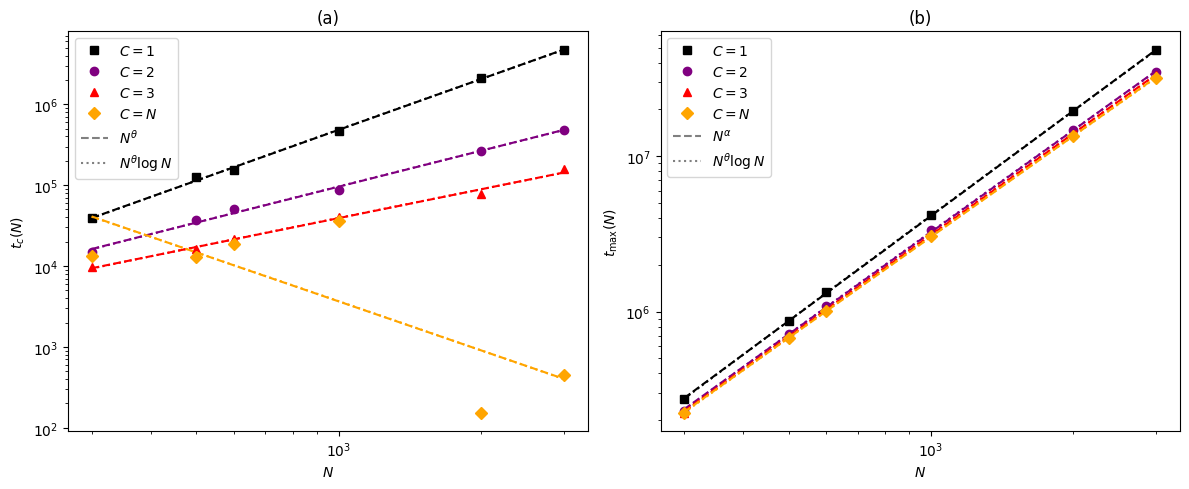


ESCALA DA RAZÃO t_c / t_max

$C=1$
t_c/t_max ~ N^-0.160 (R² = 0.817)
N=  300 | tc/tmax=1.427375e-01
N=  500 | tc/tmax=1.432808e-01
N=  600 | tc/tmax=1.138132e-01
N= 1000 | tc/tmax=1.134698e-01
N= 2000 | tc/tmax=1.069859e-01
N= 3000 | tc/tmax=9.843845e-02

$C=2$
t_c/t_max ~ N^-0.705 (R² = 0.982)
N=  300 | tc/tmax=6.421216e-02
N=  500 | tc/tmax=5.190218e-02
N=  600 | tc/tmax=4.642400e-02
N= 1000 | tc/tmax=2.613368e-02
N= 2000 | tc/tmax=1.818588e-02
N= 3000 | tc/tmax=1.376305e-02

$C=3$
t_c/t_max ~ N^-0.983 (R² = 0.991)
N=  300 | tc/tmax=4.313265e-02
N=  500 | tc/tmax=2.337327e-02
N=  600 | tc/tmax=2.082598e-02
N= 1000 | tc/tmax=1.292402e-02
N= 2000 | tc/tmax=5.594295e-03
N= 3000 | tc/tmax=4.708665e-03

$C=N$
t_c/t_max ~ N^-4.164 (R² = 0.868)
N=  300 | tc/tmax=6.011944e-02
N=  500 | tc/tmax=1.921253e-02
N=  600 | tc/tmax=1.855125e-02
N= 1000 | tc/tmax=1.187749e-02
N= 2000 | tc/tmax=1.122392e-05
N= 3000 | tc/tmax=1.412354e-05


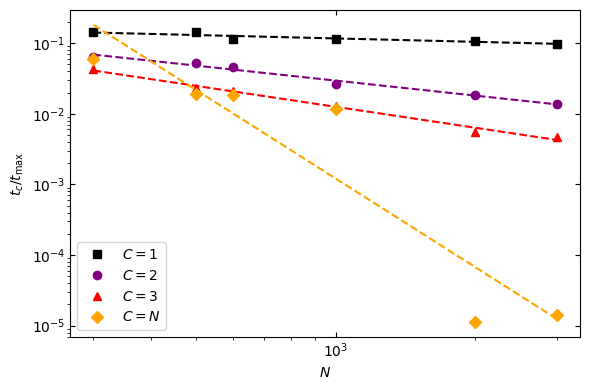


TESTE ASSINTÓTICO DE t_max

--------------------------------------------------------------------------------
$C=1$
--------------------------------------------------------------------------------

Ajuste direto: t_max ~ N^2.243 (R²=1.000)

Constantes a = t_max/N²:
N= 300 -> 3.030867
N= 500 -> 3.483544
N= 600 -> 3.722577
N=1000 -> 4.172322
N=2000 -> 4.891674
N=3000 -> 5.333473

Melhor expoente (min Var[log]): alpha = 2.2425


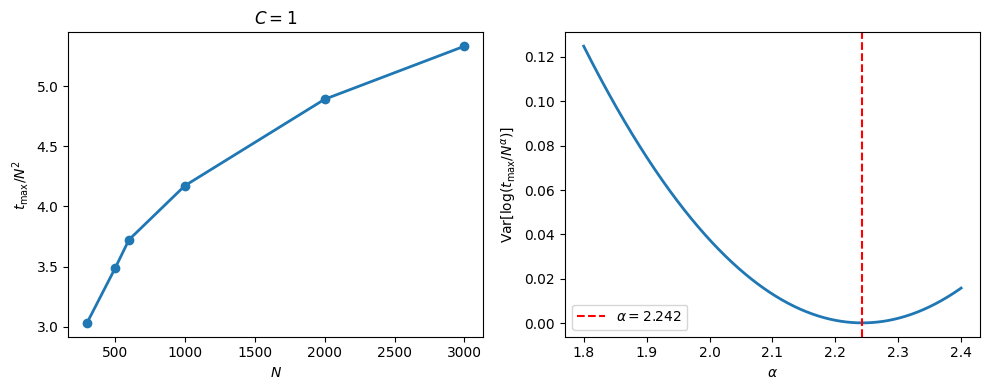


--------------------------------------------------------------------------------
$C=2$
--------------------------------------------------------------------------------

Ajuste direto: t_max ~ N^2.178 (R²=1.000)

Constantes a = t_max/N²:
N= 300 -> 2.564073
N= 500 -> 2.851647
N= 600 -> 3.010091
N=1000 -> 3.332021
N=2000 -> 3.665683
N=3000 -> 3.877354

Melhor expoente (min Var[log]): alpha = 2.1788


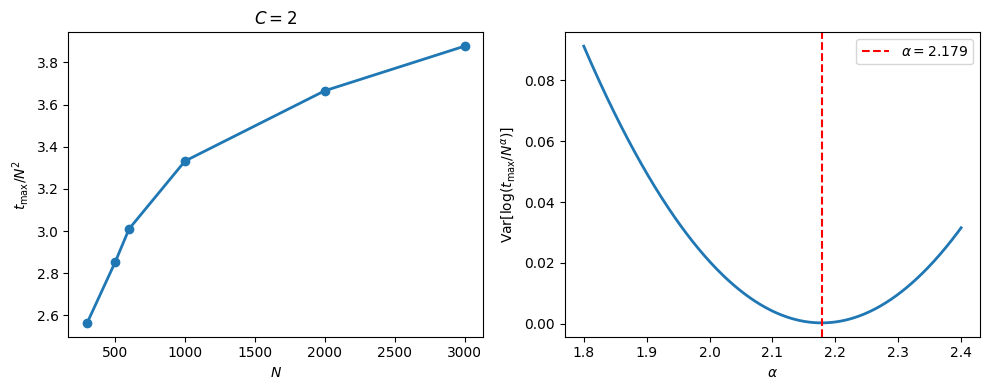


--------------------------------------------------------------------------------
$C=3$
--------------------------------------------------------------------------------

Ajuste direto: t_max ~ N^2.167 (R²=1.000)

Constantes a = t_max/N²:
N= 300 -> 2.492932
N= 500 -> 2.791834
N= 600 -> 2.895861
N=1000 -> 3.143208
N=2000 -> 3.472027
N=3000 -> 3.714158

Melhor expoente (min Var[log]): alpha = 2.1679


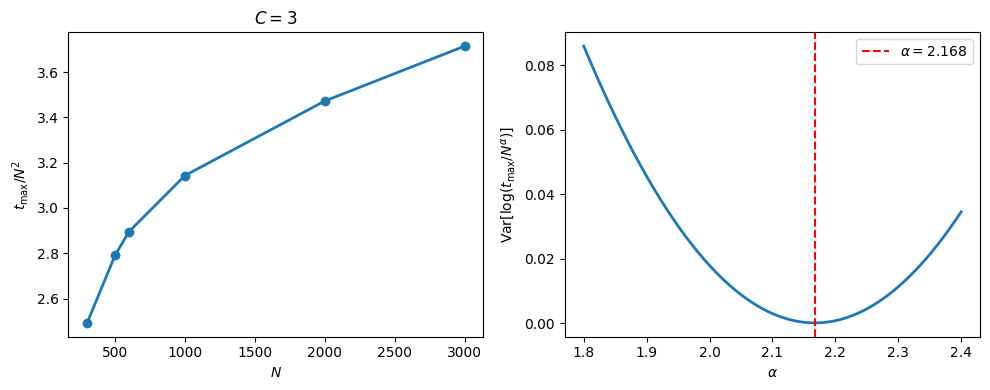


--------------------------------------------------------------------------------
$C=N$
--------------------------------------------------------------------------------

Ajuste direto: t_max ~ N^2.155 (R²=1.000)

Constantes a = t_max/N²:
N= 300 -> 2.477332
N= 500 -> 2.722409
N= 600 -> 2.815798
N=1000 -> 3.054945
N=2000 -> 3.392688
N=3000 -> 3.537972

Melhor expoente (min Var[log]): alpha = 2.1547


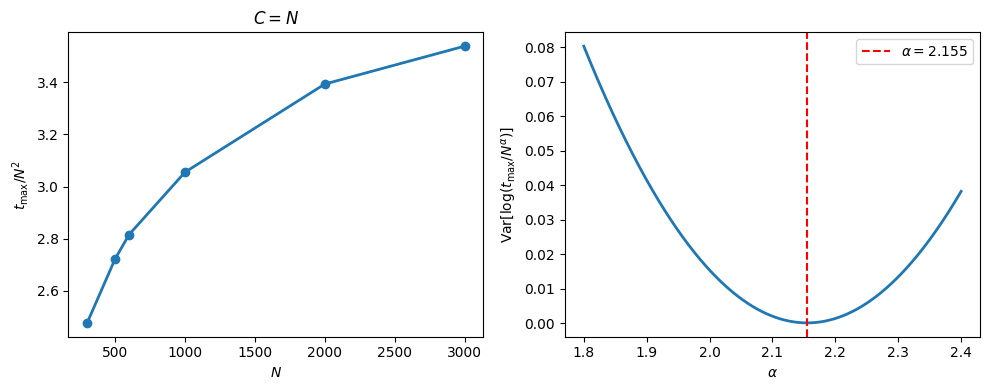


RESUMO NO FORMATO DO ARTIGO
C finito: usar theta de t_c(N) e conferir com theta de t_max(N) ~ N^theta log(N)
C=N: usar theta_minus de t_c(N) e theta_plus de t_max(N) ~ N^theta log(N)

--------------------------------------------------------------------------------
$C=1$
--------------------------------------------------------------------------------
theta (de t_c): 2.083 ± 0.033 (R²=0.999)
theta (de t_max/logN): 2.097 ± 0.005 (R²=1.000)

--------------------------------------------------------------------------------
$C=2$
--------------------------------------------------------------------------------
theta (de t_c): 1.474 ± 0.047 (R²=0.996)
theta (de t_max/logN): 2.032 ± 0.008 (R²=1.000)

--------------------------------------------------------------------------------
$C=3$
--------------------------------------------------------------------------------
theta (de t_c): 1.184 ± 0.046 (R²=0.994)
theta (de t_max/logN): 2.021 ± 0.004 (R²=1.000)

-----------------------------------------

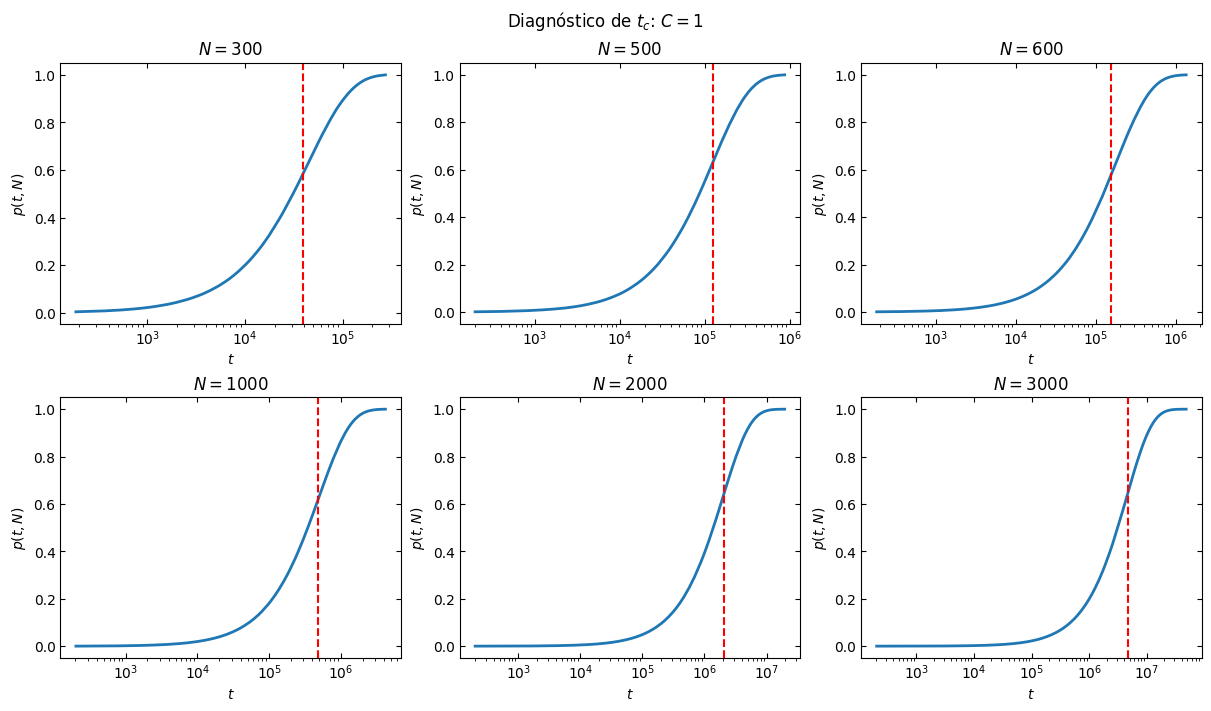

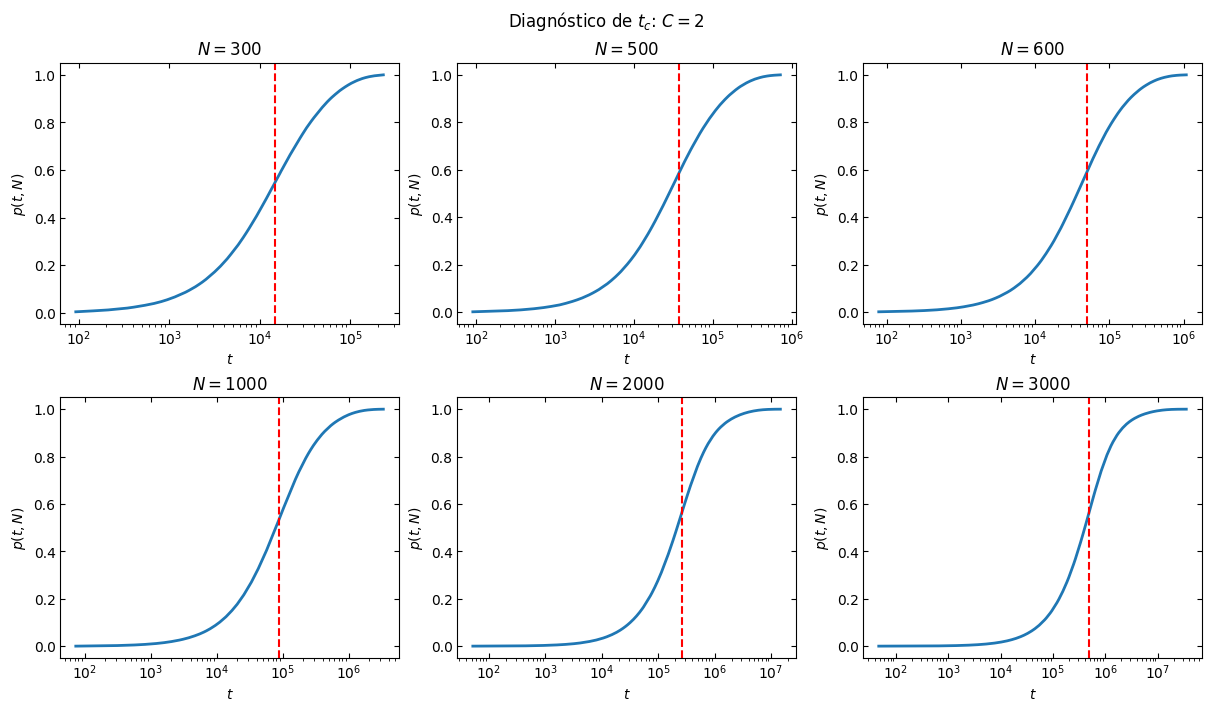

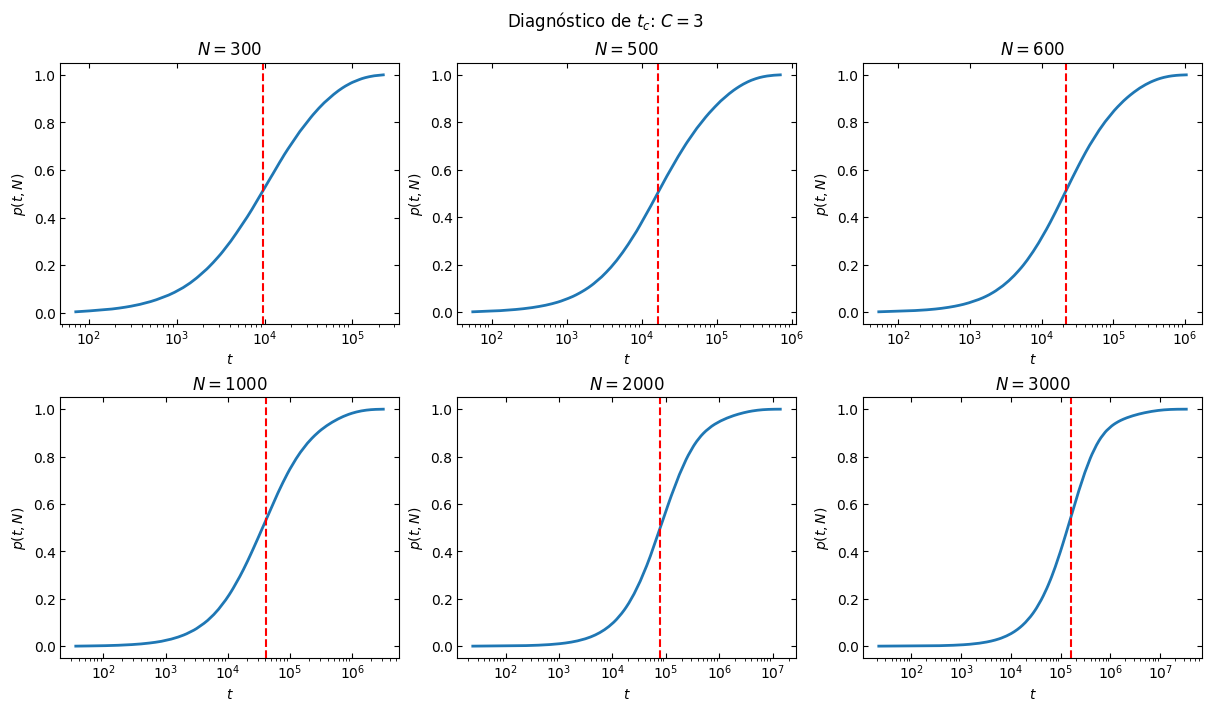

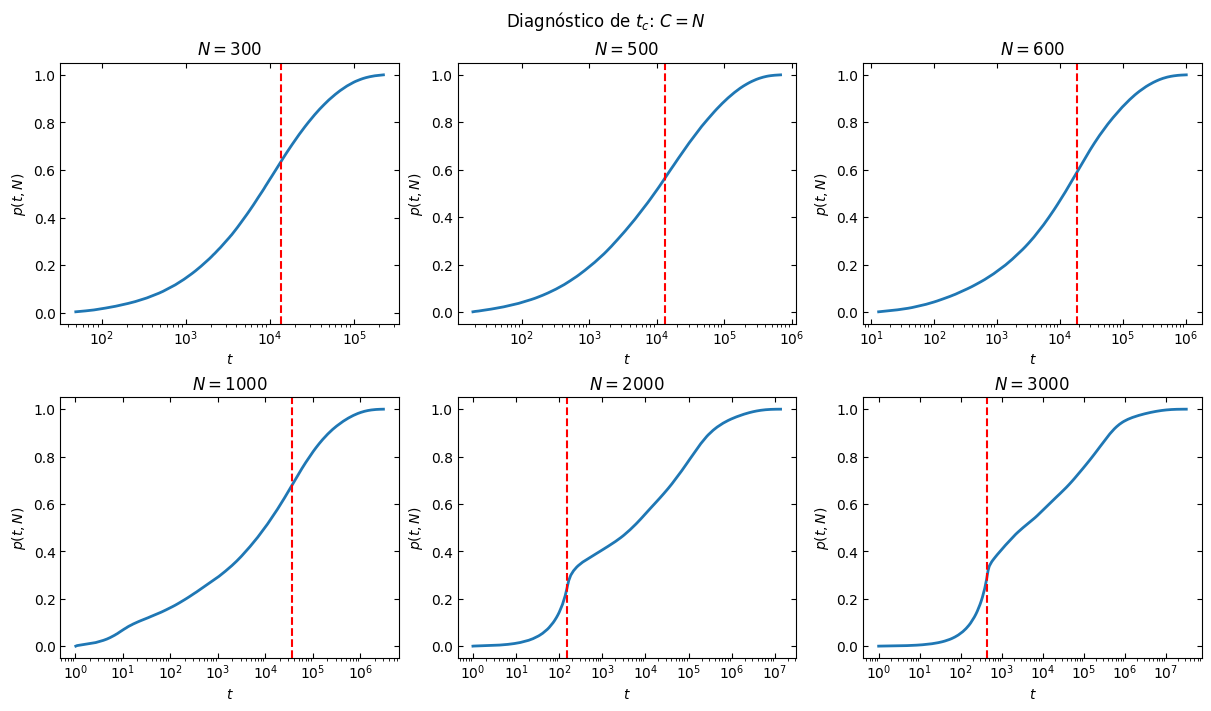


THETA PARA COLAPSO (LINHA DO ARTIGO)
C=1: theta = 2.083 (de t_c)
C=2: theta = 1.474 (de t_c)
C=3: theta = 1.184 (de t_c)
C=N: theta_minus = -2.009 (de t_c)
C=N: theta_plus  = 2.009 (de t_max/logN)


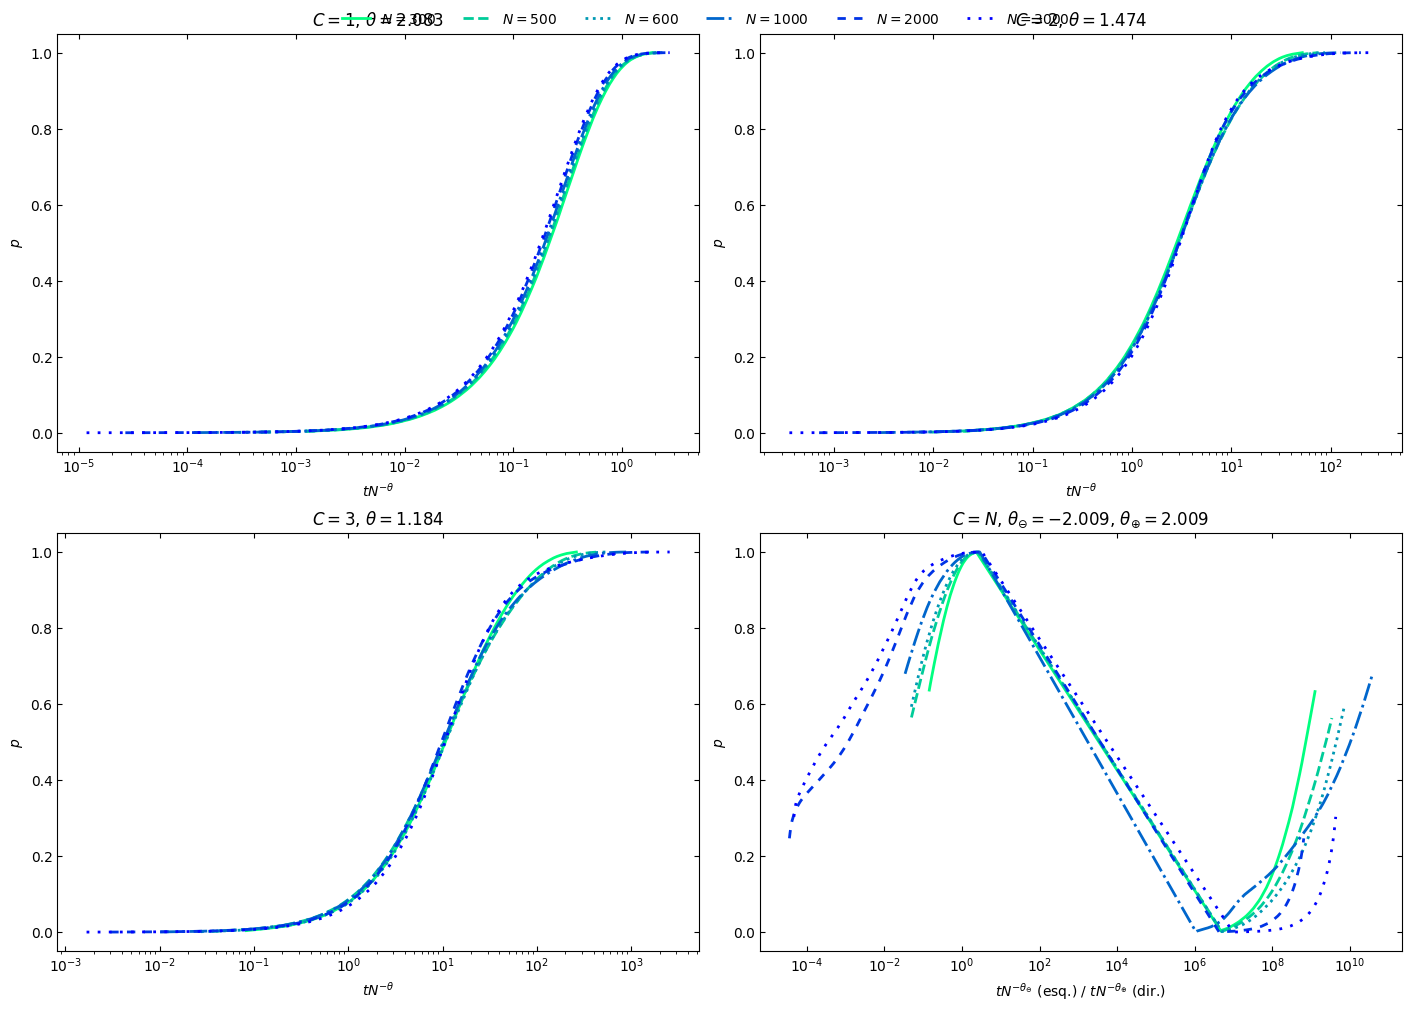

In [35]:
results = plot_final(mode="random")


TESTE ASSINTOTICO DE t_c: N^a vs N^a log(N)

--------------------------------------------------------------------------------
$C=1$
--------------------------------------------------------------------------------
Ajuste puro:      t_c ~ N^2.0832
Ajuste com log:   t_c ~ N^1.9369 log(N)
R2(log-espaco):   puro=0.99897 | log=0.99894 -> favorece N^a
AIC(log-espaco):  puro=-31.172 | log=-30.989 -> favorece N^a
Flatness(min Var): puro=2.84782e-03 | log=2.93700e-03 -> favorece N^a
Consenso: N^a


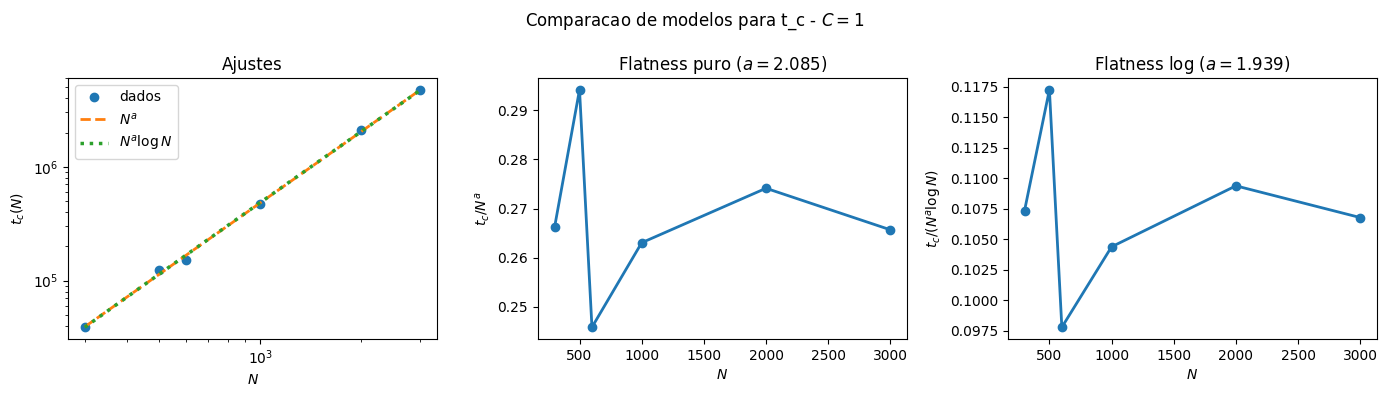


--------------------------------------------------------------------------------
$C=2$
--------------------------------------------------------------------------------
Ajuste puro:      t_c ~ N^1.4735
Ajuste com log:   t_c ~ N^1.3272 log(N)
R2(log-espaco):   puro=0.99587 | log=0.99606 -> favorece N^a log(N)
AIC(log-espaco):  puro=-26.976 | log=-27.254 -> favorece N^a log(N)
Flatness(min Var): puro=5.72789e-03 | log=5.46832e-03 -> favorece N^a log(N)
Consenso: N^a log(N)


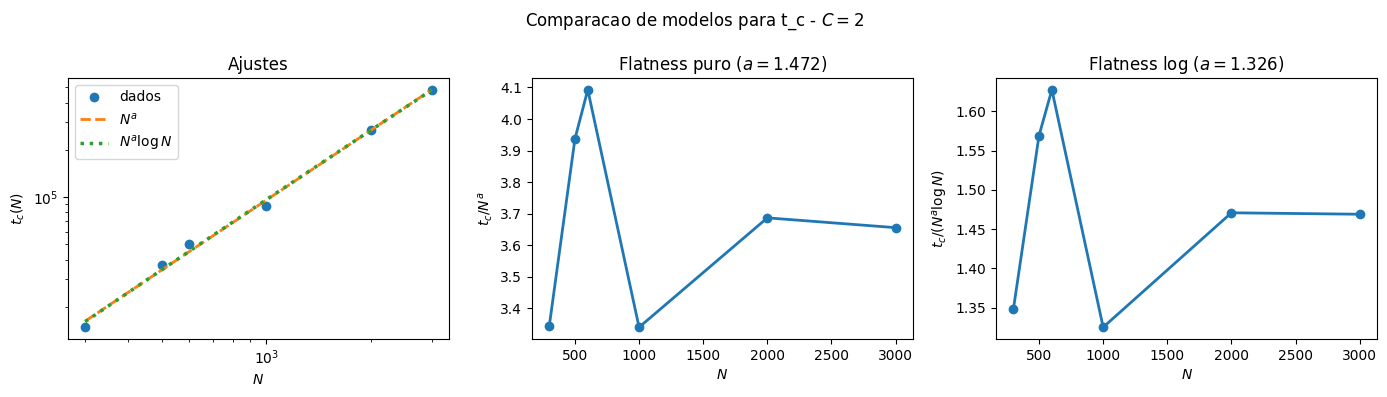


--------------------------------------------------------------------------------
$C=3$
--------------------------------------------------------------------------------
Ajuste puro:      t_c ~ N^1.1841
Ajuste com log:   t_c ~ N^1.0378 log(N)
R2(log-espaco):   puro=0.99409 | log=0.99377 -> favorece N^a
AIC(log-espaco):  puro=-27.435 | log=-27.121 -> favorece N^a
Flatness(min Var): puro=5.30678e-03 | log=5.59328e-03 -> favorece N^a
Consenso: N^a


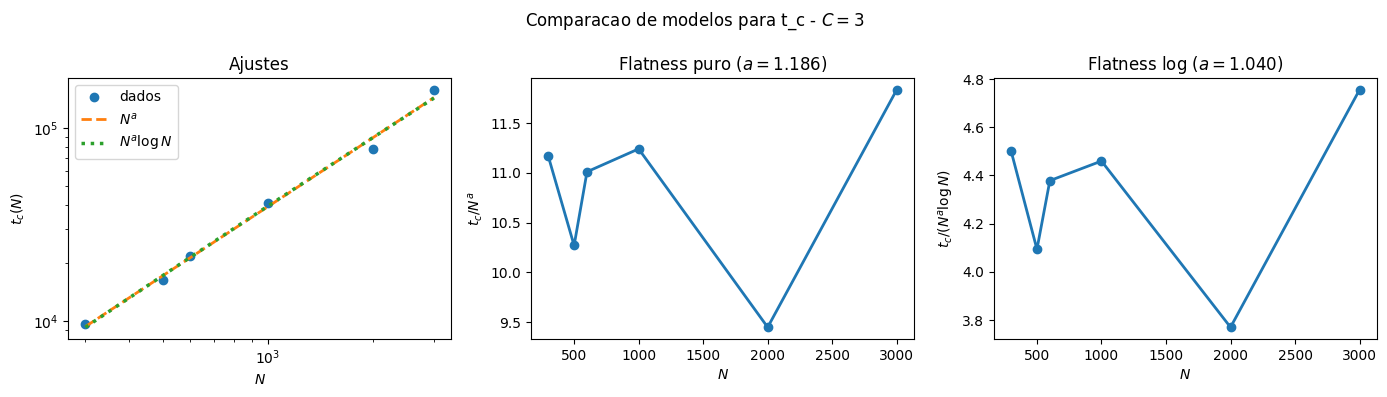


--------------------------------------------------------------------------------
$C=N$
--------------------------------------------------------------------------------
Ajuste puro:      t_c ~ N^-2.0085
Ajuste com log:   t_c ~ N^-2.1548 log(N)
R2(log-espaco):   puro=0.60355 | log=0.60553 -> favorece N^a log(N)
AIC(log-espaco):  puro=7.130 | log=7.100 -> favorece N^a log(N)
Flatness(min Var): puro=1.68491e+00 | log=1.67652e+00 -> favorece N^a log(N)
Consenso: N^a log(N)


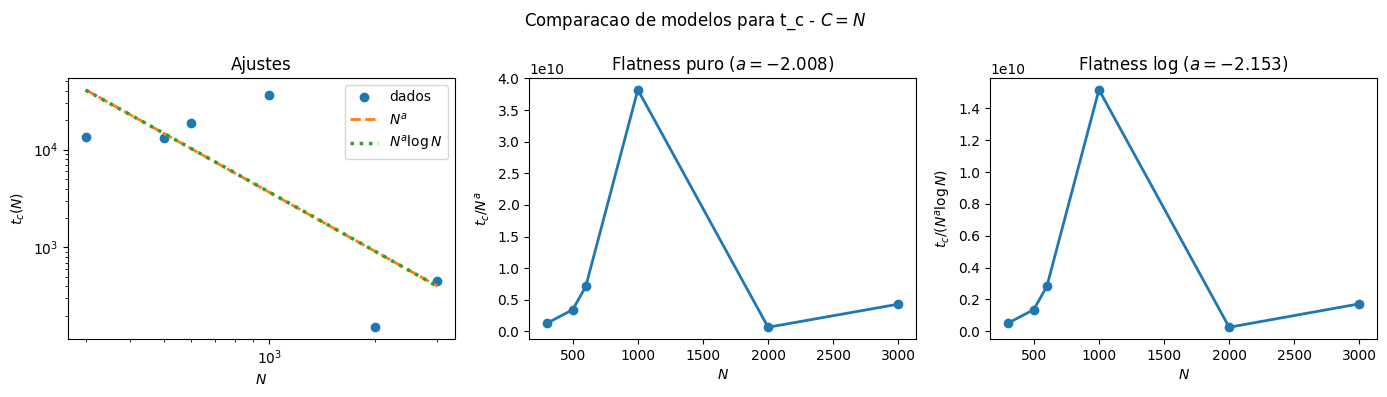

In [36]:
def _logfit_metrics(y_true, y_hat, k):
    y_true = np.asarray(y_true, float)
    y_hat = np.asarray(y_hat, float)
    mask = np.isfinite(y_true) & np.isfinite(y_hat)
    y_true = y_true[mask]
    y_hat = y_hat[mask]
    n = len(y_true)
    if n <= k + 1:
        return {"r2": np.nan, "aic": np.nan, "bic": np.nan, "rss": np.nan}

    rss = float(np.sum((y_true - y_hat) ** 2))
    tss = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2 = 1.0 - rss / tss if tss > 0 else np.nan

    # Mesma forma da gaussiana em mínimos quadrados; k é igual nos dois modelos.
    sigma2 = max(rss / n, 1e-30)
    aic = n * np.log(sigma2) + 2 * k
    bic = n * np.log(sigma2) + k * np.log(n)
    return {"r2": r2, "aic": float(aic), "bic": float(bic), "rss": rss}


def _best_theta_by_flatness(Ns, ys, use_log_correction=False):
    Ns = np.asarray(Ns, float)
    ys = np.asarray(ys, float)
    mask = np.isfinite(Ns) & np.isfinite(ys) & (Ns > 1.0) & (ys > 0)
    Ns = Ns[mask]
    ys = ys[mask]
    if len(Ns) < 3:
        return np.nan, np.nan

    thetas = np.linspace(-3.0, 4.0, 1200)
    if use_log_correction:
        vals = np.array([
            np.var(np.log(ys / (Ns ** th * np.log(Ns)))) for th in thetas
        ])
    else:
        vals = np.array([
            np.var(np.log(ys / (Ns ** th))) for th in thetas
        ])

    i_best = int(np.argmin(vals))
    return float(thetas[i_best]), float(vals[i_best])


def test_tc_scaling_vs_log(Ns, tcs_dict):
    print("\n" + "=" * 80)
    print("TESTE ASSINTOTICO DE t_c: N^a vs N^a log(N)")
    print("=" * 80)

    for label, tcs in tcs_dict.items():
        Ns_ok = np.asarray(Ns, float)
        tcs_ok = np.asarray(tcs, float)
        mask = np.isfinite(Ns_ok) & np.isfinite(tcs_ok) & (Ns_ok > 1.0) & (tcs_ok > 0)
        Ns_ok = Ns_ok[mask]
        tcs_ok = tcs_ok[mask]

        if len(Ns_ok) < 3:
            print(f"\n{label}: poucos pontos para comparar modelos")
            continue

        print("\n" + "-" * 80)
        print(label)
        print("-" * 80)

        theta_pure, b_pure, _ = fit_power_law(Ns_ok, tcs_ok)
        theta_log, b_log, _ = fit_power_law_times_log(Ns_ok, tcs_ok, log_power=1.0)

        logN = np.log(Ns_ok)
        loglogN = np.log(logN)
        logy = np.log(tcs_ok)
        logy_hat_pure = b_pure + theta_pure * logN
        logy_hat_log = b_log + theta_log * logN + loglogN

        m_pure = _logfit_metrics(logy, logy_hat_pure, k=2)
        m_log = _logfit_metrics(logy, logy_hat_log, k=2)

        theta_flat_pure, var_flat_pure = _best_theta_by_flatness(
            Ns_ok, tcs_ok, use_log_correction=False
        )
        theta_flat_log, var_flat_log = _best_theta_by_flatness(
            Ns_ok, tcs_ok, use_log_correction=True
        )

        winner_r2 = "N^a log(N)" if m_log["r2"] > m_pure["r2"] else "N^a"
        winner_aic = "N^a log(N)" if m_log["aic"] < m_pure["aic"] else "N^a"
        winner_flat = "N^a log(N)" if var_flat_log < var_flat_pure else "N^a"

        print(f"Ajuste puro:      t_c ~ N^{theta_pure:.4f}")
        print(f"Ajuste com log:   t_c ~ N^{theta_log:.4f} log(N)")
        print(f"R2(log-espaco):   puro={m_pure['r2']:.5f} | log={m_log['r2']:.5f} -> favorece {winner_r2}")
        print(f"AIC(log-espaco):  puro={m_pure['aic']:.3f} | log={m_log['aic']:.3f} -> favorece {winner_aic}")
        print(f"Flatness(min Var): puro={var_flat_pure:.5e} | log={var_flat_log:.5e} -> favorece {winner_flat}")
        print(
            "Consenso: "
            + (
                winner_r2 if (winner_r2 == winner_aic == winner_flat)
                else f"misto (R2:{winner_r2}, AIC:{winner_aic}, flatness:{winner_flat})"
            )
        )

        nfit = np.logspace(np.log10(np.min(Ns_ok)), np.log10(np.max(Ns_ok)), 300)
        fig, ax = plt.subplots(1, 3, figsize=(14, 4))

        ax[0].loglog(Ns_ok, tcs_ok, "o", ms=6, label="dados")
        ax[0].loglog(nfit, np.exp(b_pure) * nfit ** theta_pure, "--", lw=2, label=r"$N^a$")
        ax[0].loglog(
            nfit,
            np.exp(b_log) * nfit ** theta_log * np.log(nfit),
            ":",
            lw=2.5,
            label=r"$N^a\log N$",
        )
        ax[0].set_xlabel(r"$N$")
        ax[0].set_ylabel(r"$t_c(N)$")
        ax[0].set_title("Ajustes")
        ax[0].legend()

        ratio_pure = tcs_ok / (Ns_ok ** theta_flat_pure)
        ratio_log = tcs_ok / (Ns_ok ** theta_flat_log * np.log(Ns_ok))

        ax[1].plot(Ns_ok, ratio_pure, "o-", lw=2)
        ax[1].set_xlabel(r"$N$")
        ax[1].set_ylabel(r"$t_c/N^a$")
        ax[1].set_title(rf"Flatness puro ($a={theta_flat_pure:.3f}$)")

        ax[2].plot(Ns_ok, ratio_log, "o-", lw=2)
        ax[2].set_xlabel(r"$N$")
        ax[2].set_ylabel(r"$t_c/(N^a\log N)$")
        ax[2].set_title(rf"Flatness log ($a={theta_flat_log:.3f}$)")

        plt.suptitle(f"Comparacao de modelos para t_c - {label}")
        plt.tight_layout()
        plt.show()


test_tc_scaling_vs_log(results["Ns"], results["tcs_dict"])


ANALISE t_c COM MODELO GERAL: t_c = A N^a (log N)^b

--------------------------------------------------------------------------------
$C=1$
--------------------------------------------------------------------------------
Puro:      a=2.0832, R2=0.99897, AICc=-27.172
Log fixo:  a=1.9369, b=1, R2=0.99894, AICc=-26.989
Log livre: a=2.2150 +/- 0.7998, b=-0.9008 +/- 5.4607, R2=0.99898, AICc=-17.226
Melhor por AICc: N^a


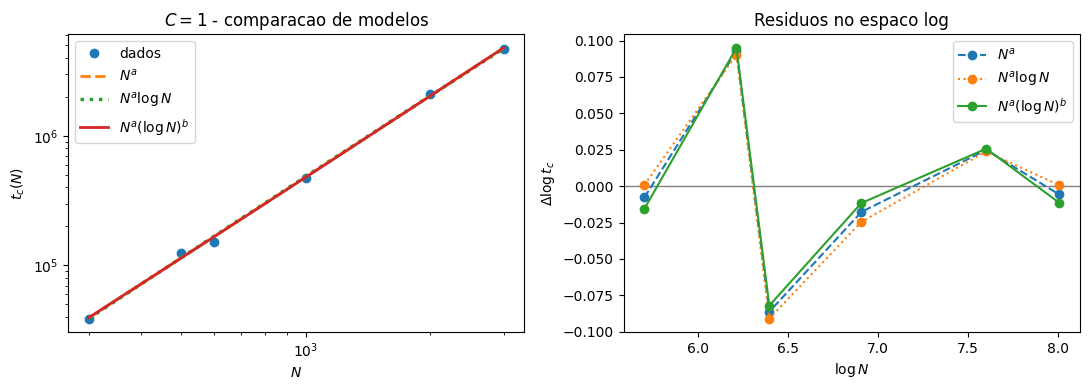


--------------------------------------------------------------------------------
$C=2$
--------------------------------------------------------------------------------
Puro:      a=1.4735, R2=0.99587, AICc=-22.976
Log fixo:  a=1.3272, b=1, R2=0.99606, AICc=-23.254
Log livre: a=0.7994 +/- 1.0710, b=4.6082 +/- 7.3126, R2=0.99635, AICc=-13.722
Melhor por AICc: N^a logN (b=1)


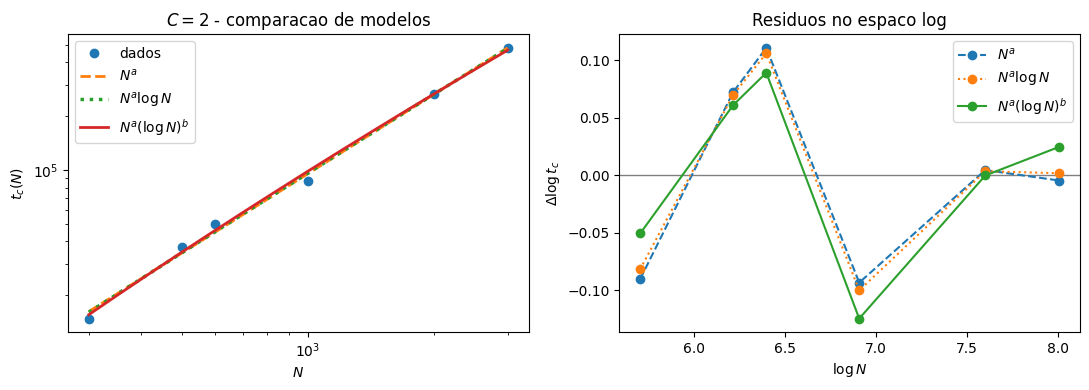


--------------------------------------------------------------------------------
$C=3$
--------------------------------------------------------------------------------
Puro:      a=1.1841, R2=0.99409, AICc=-23.435
Log fixo:  a=1.0378, b=1, R2=0.99377, AICc=-23.121
Log livre: a=1.7737 +/- 1.0426, b=-4.0302 +/- 7.1187, R2=0.99466, AICc=-14.044
Melhor por AICc: N^a


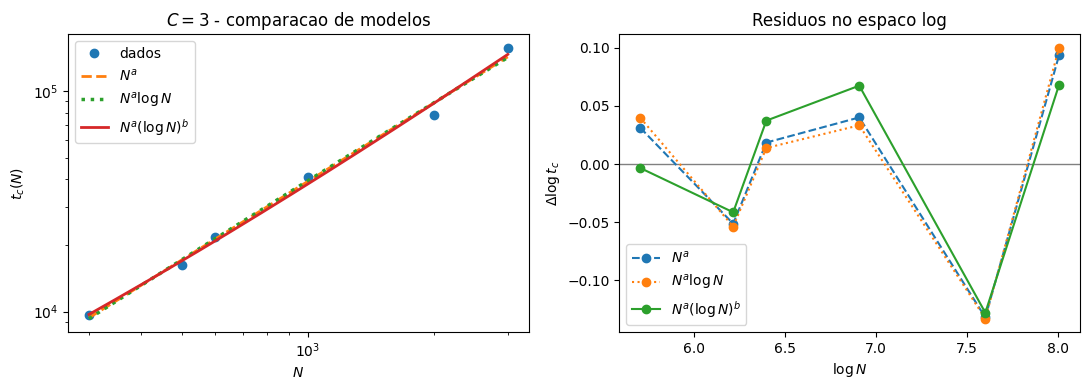


--------------------------------------------------------------------------------
$C=N$
--------------------------------------------------------------------------------
Puro:      a=-2.0085, R2=0.60355, AICc=11.130
Log fixo:  a=-2.1548, b=1, R2=0.60553, AICc=11.100
Log livre: a=-21.5562 +/- 15.9530, b=133.6226 +/- 108.9247, R2=0.73599, AICc=18.691
Melhor por AICc: N^a logN (b=1)


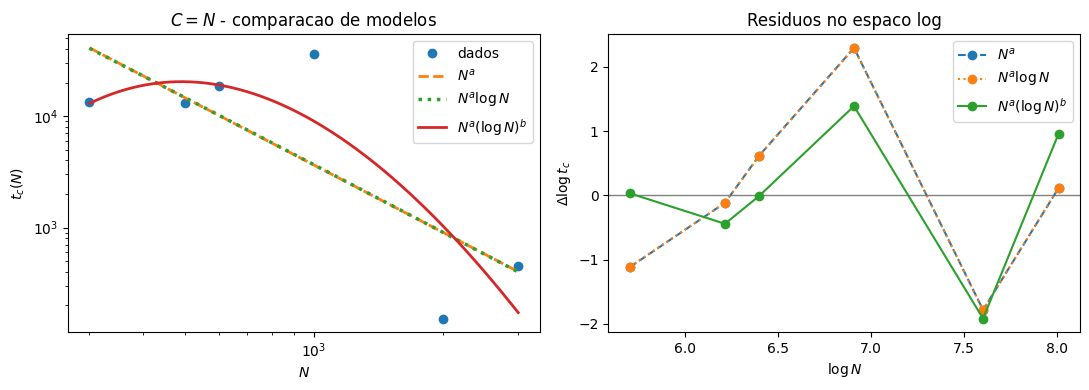

In [37]:
def fit_power_log_power_with_error(x, y):
    """Ajusta y = A * N^a * (log N)^b no espaço log: log y = c + a logN + b loglogN."""
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 1.0) & (y > 0)
    x, y = x[mask], y[mask]

    n = len(x)
    if n < 4:
        return None

    logx = np.log(x)
    loglogx = np.log(logx)
    logy = np.log(y)

    X = np.column_stack([np.ones(n), logx, loglogx])
    beta, _, _, _ = np.linalg.lstsq(X, logy, rcond=None)
    c, a, b = beta

    logy_hat = X @ beta
    resid = logy - logy_hat
    rss = float(np.sum(resid ** 2))
    tss = float(np.sum((logy - np.mean(logy)) ** 2))
    r2 = 1.0 - rss / tss if tss > 0 else np.nan

    dof = n - 3
    if dof > 0:
        sigma2 = rss / dof
        cov = sigma2 * np.linalg.inv(X.T @ X)
        c_err = float(np.sqrt(cov[0, 0])) if cov[0, 0] > 0 else np.nan
        a_err = float(np.sqrt(cov[1, 1])) if cov[1, 1] > 0 else np.nan
        b_err = float(np.sqrt(cov[2, 2])) if cov[2, 2] > 0 else np.nan
    else:
        c_err = np.nan
        a_err = np.nan
        b_err = np.nan

    # AICc no espaço log; útil para N pequeno.
    k = 3
    sigma2_mle = max(rss / n, 1e-30)
    aic = n * np.log(sigma2_mle) + 2 * k
    aicc = np.nan
    if n > k + 1:
        aicc = aic + (2 * k * (k + 1)) / (n - k - 1)

    return {
        "A": float(np.exp(c)),
        "A_err": float(np.exp(c) * c_err) if np.isfinite(c_err) else np.nan,
        "a": float(a),
        "a_err": a_err,
        "b": float(b),
        "b_err": b_err,
        "c": float(c),
        "r2": float(r2),
        "rss": rss,
        "aicc": float(aicc) if np.isfinite(aicc) else np.nan,
    }


def _aicc_log_model(logy, logy_hat, k):
    logy = np.asarray(logy, float)
    logy_hat = np.asarray(logy_hat, float)
    n = len(logy)
    if n <= k + 1:
        return np.nan
    rss = float(np.sum((logy - logy_hat) ** 2))
    sigma2_mle = max(rss / n, 1e-30)
    aic = n * np.log(sigma2_mle) + 2 * k
    return float(aic + (2 * k * (k + 1)) / (n - k - 1))


def analyze_tc_general_log_power(Ns, tcs_dict):
    print("\n" + "=" * 80)
    print("ANALISE t_c COM MODELO GERAL: t_c = A N^a (log N)^b")
    print("=" * 80)

    for label, tcs in tcs_dict.items():
        x = np.asarray(Ns, float)
        y = np.asarray(tcs, float)
        mask = np.isfinite(x) & np.isfinite(y) & (x > 1.0) & (y > 0)
        x, y = x[mask], y[mask]

        if len(x) < 4:
            print(f"\n{label}: pontos insuficientes para ajustar b livre")
            continue

        fit_free = fit_power_log_power_with_error(x, y)
        a_pure, c_pure, r2_pure = fit_power_law(x, y)
        a_log1, c_log1, r2_log1 = fit_power_law_times_log(x, y, log_power=1.0)

        lx = np.log(x)
        llx = np.log(lx)
        ly = np.log(y)

        ly_hat_pure = c_pure + a_pure * lx
        ly_hat_log1 = c_log1 + a_log1 * lx + llx
        ly_hat_free = fit_free["c"] + fit_free["a"] * lx + fit_free["b"] * llx

        aicc_pure = _aicc_log_model(ly, ly_hat_pure, k=2)
        aicc_log1 = _aicc_log_model(ly, ly_hat_log1, k=2)
        aicc_free = _aicc_log_model(ly, ly_hat_free, k=3)

        aicc_vals = {
            "N^a": aicc_pure,
            "N^a logN (b=1)": aicc_log1,
            "N^a (logN)^b": aicc_free,
        }
        finite_items = [(k, v) for k, v in aicc_vals.items() if np.isfinite(v)]
        best_name = min(finite_items, key=lambda kv: kv[1])[0] if finite_items else "indefinido"

        print("\n" + "-" * 80)
        print(label)
        print("-" * 80)
        print(f"Puro:      a={a_pure:.4f}, R2={r2_pure:.5f}, AICc={aicc_pure:.3f}")
        print(f"Log fixo:  a={a_log1:.4f}, b=1, R2={r2_log1:.5f}, AICc={aicc_log1:.3f}")
        print(
            f"Log livre: a={fit_free['a']:.4f} +/- {fit_free['a_err']:.4f}, "
            f"b={fit_free['b']:.4f} +/- {fit_free['b_err']:.4f}, "
            f"R2={fit_free['r2']:.5f}, AICc={fit_free['aicc']:.3f}"
        )
        print(f"Melhor por AICc: {best_name}")

        nfit = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), 300)
        y_pure = np.exp(c_pure) * nfit ** a_pure
        y_log1 = np.exp(c_log1) * nfit ** a_log1 * np.log(nfit)
        y_free = fit_free["A"] * nfit ** fit_free["a"] * np.log(nfit) ** fit_free["b"]

        fig, ax = plt.subplots(1, 2, figsize=(11, 4))
        ax[0].loglog(x, y, "o", ms=6, label="dados")
        ax[0].loglog(nfit, y_pure, "--", lw=2, label=r"$N^a$")
        ax[0].loglog(nfit, y_log1, ":", lw=2.5, label=r"$N^a\log N$")
        ax[0].loglog(nfit, y_free, "-", lw=2, label=r"$N^a(\log N)^b$")
        ax[0].set_xlabel(r"$N$")
        ax[0].set_ylabel(r"$t_c(N)$")
        ax[0].set_title(f"{label} - comparacao de modelos")
        ax[0].legend()

        resid_pure = ly - ly_hat_pure
        resid_log1 = ly - ly_hat_log1
        resid_free = ly - ly_hat_free
        ax[1].axhline(0.0, color="gray", lw=1)
        ax[1].plot(lx, resid_pure, "o--", label=r"$N^a$")
        ax[1].plot(lx, resid_log1, "o:", label=r"$N^a\log N$")
        ax[1].plot(lx, resid_free, "o-", label=r"$N^a(\log N)^b$")
        ax[1].set_xlabel(r"$\log N$")
        ax[1].set_ylabel(r"$\Delta\log t_c$")
        ax[1].set_title("Residuos no espaco log")
        ax[1].legend()

        plt.tight_layout()
        plt.show()


analyze_tc_general_log_power(results["Ns"], results["tcs_dict"])


ANALISE t_c (R2 + AIC): N^a vs N^a logN vs N^a (logN)^b

--------------------------------------------------------------------------------
$C=1$
--------------------------------------------------------------------------------
N^a:            a=2.083197, b=0.0, R2=0.998970, AIC=-31.172
N^a logN (fixo):a=1.936907, b=1.0, R2=0.998938, AIC=-30.989
N^a (logN)^b:   a=2.214973, b=-0.900784, R2=0.998979, AIC=-29.226
Melhor por R2: N^a (logN)^b
Melhor por AIC: N^a


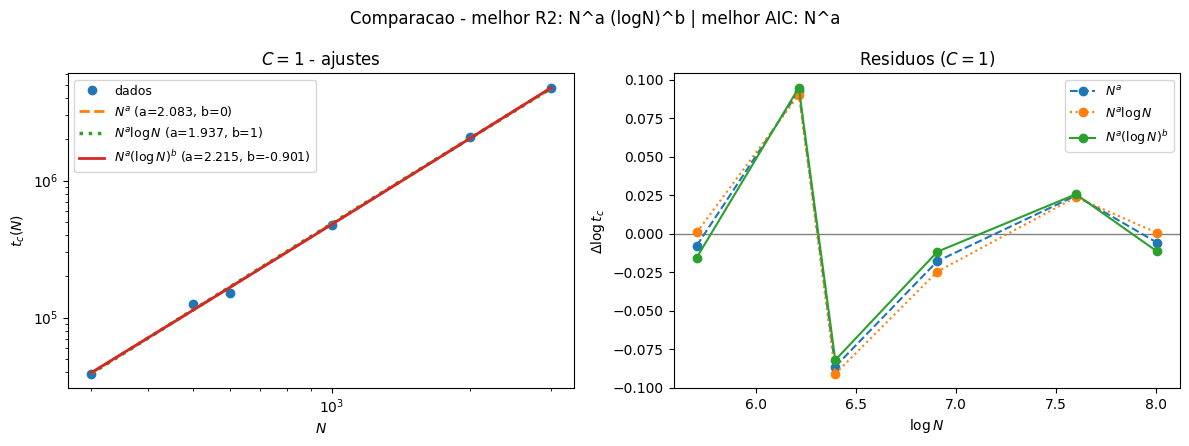


--------------------------------------------------------------------------------
$C=2$
--------------------------------------------------------------------------------
N^a:            a=1.473513, b=0.0, R2=0.995869, AIC=-26.976
N^a logN (fixo):a=1.327223, b=1.0, R2=0.996056, AIC=-27.254
N^a (logN)^b:   a=0.799379, b=4.608208, R2=0.996352, AIC=-25.722
Melhor por R2: N^a (logN)^b
Melhor por AIC: N^a logN (b=1)


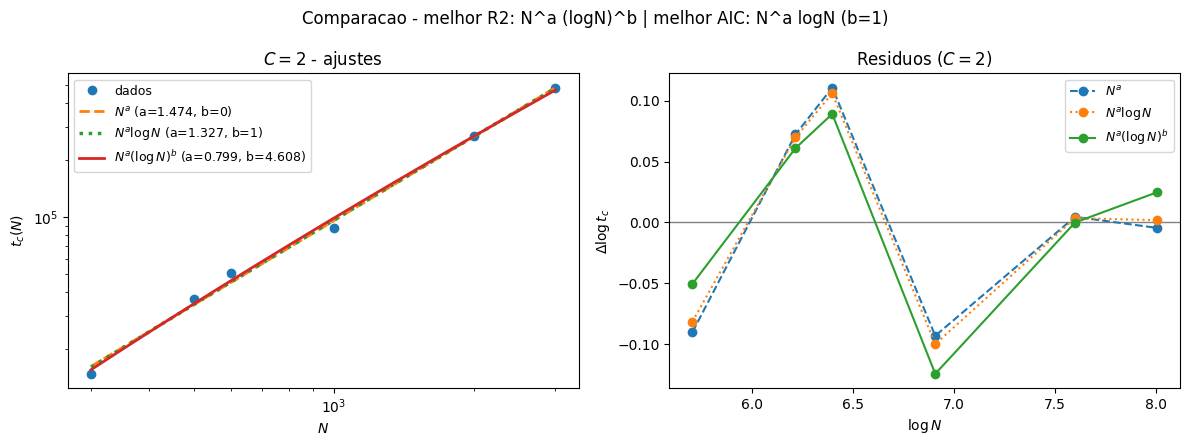


--------------------------------------------------------------------------------
$C=3$
--------------------------------------------------------------------------------
N^a:            a=1.184089, b=0.0, R2=0.994085, AIC=-27.435
N^a logN (fixo):a=1.037799, b=1.0, R2=0.993767, AIC=-27.121
N^a (logN)^b:   a=1.773670, b=-4.030223, R2=0.994656, AIC=-26.044
Melhor por R2: N^a (logN)^b
Melhor por AIC: N^a


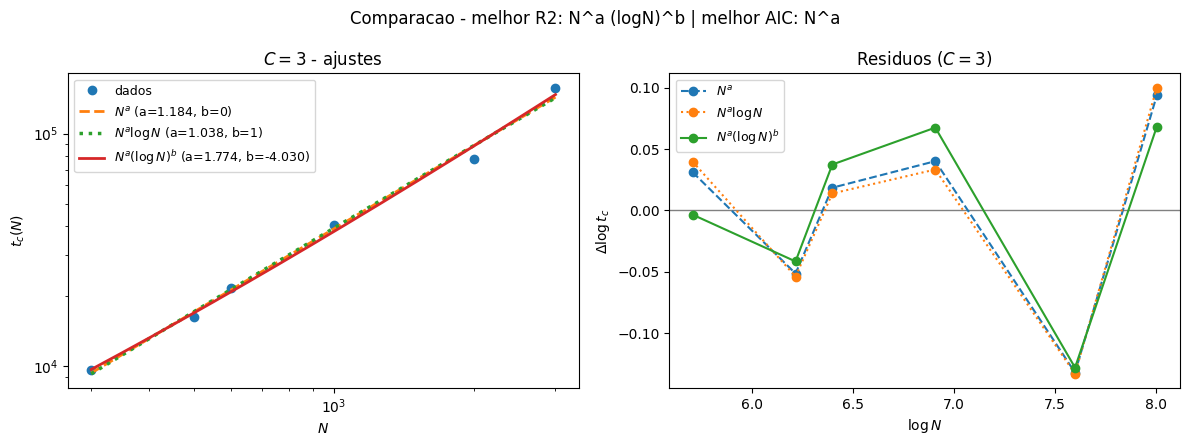


--------------------------------------------------------------------------------
$C=N$
--------------------------------------------------------------------------------
N^a:            a=-2.008523, b=0.0, R2=0.603551, AIC=7.130
N^a logN (fixo):a=-2.154813, b=1.0, R2=0.605526, AIC=7.100
N^a (logN)^b:   a=-21.556162, b=133.622559, R2=0.735988, AIC=6.691
Melhor por R2: N^a (logN)^b
Melhor por AIC: N^a (logN)^b


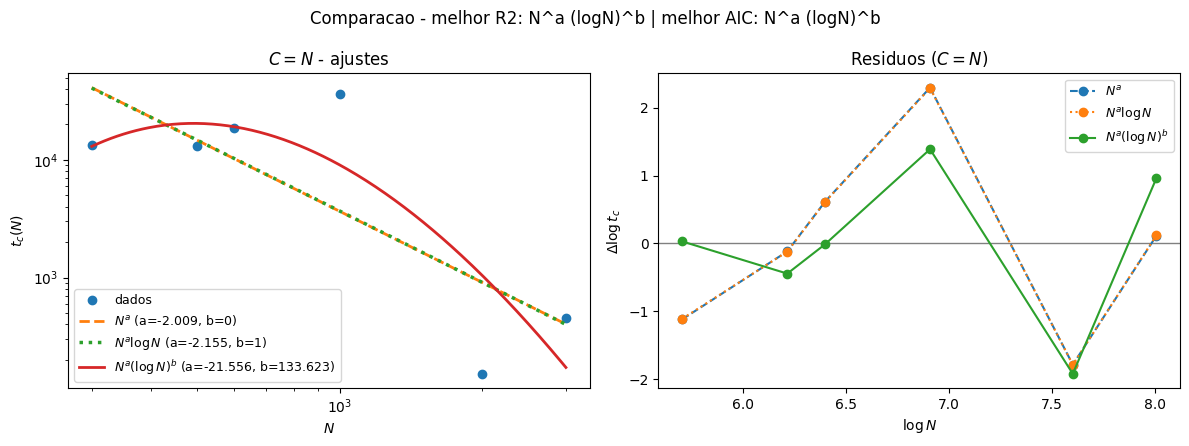

In [41]:
def analyze_tc_general_log_power_r2_only(Ns, tcs_dict):
    print("\n" + "=" * 80)
    print("ANALISE t_c (R2 + AIC): N^a vs N^a logN vs N^a (logN)^b")
    print("=" * 80)

    for label, tcs in tcs_dict.items():
        x = np.asarray(Ns, float)
        y = np.asarray(tcs, float)
        mask = np.isfinite(x) & np.isfinite(y) & (x > 1.0) & (y > 0)
        x, y = x[mask], y[mask]

        if len(x) < 4:
            print(f"\n{label}: pontos insuficientes")
            continue

        a_pure, c_pure, r2_pure = fit_power_law(x, y)
        a_log1, c_log1, r2_log1 = fit_power_law_times_log(x, y, log_power=1.0)
        fit_free = fit_power_log_power_with_error(x, y)

        b_pure = 0.0
        b_log1 = 1.0
        a_free = fit_free["a"] if fit_free is not None else np.nan
        b_free = fit_free["b"] if fit_free is not None else np.nan
        r2_free = fit_free["r2"] if fit_free is not None else np.nan

        logx = np.log(x)
        logy = np.log(y)
        logy_hat_pure = c_pure + a_pure * logx
        logy_hat_log1 = c_log1 + a_log1 * logx + np.log(logx)
        m_pure = _logfit_metrics(logy, logy_hat_pure, k=2)
        m_log1 = _logfit_metrics(logy, logy_hat_log1, k=2)

        aic_free = np.nan
        if fit_free is not None and np.isfinite(a_free) and np.isfinite(b_free):
            logy_hat_free = fit_free["c"] + a_free * logx + b_free * np.log(logx)
            m_free = _logfit_metrics(logy, logy_hat_free, k=3)
            aic_free = m_free["aic"]

        r2_vals = {
            "N^a": r2_pure,
            "N^a logN (b=1)": r2_log1,
            "N^a (logN)^b": r2_free,
        }
        aic_vals = {
            "N^a": m_pure["aic"],
            "N^a logN (b=1)": m_log1["aic"],
            "N^a (logN)^b": aic_free,
        }

        finite_r2 = [(k, v) for k, v in r2_vals.items() if np.isfinite(v)]
        best_name = max(finite_r2, key=lambda kv: kv[1])[0] if finite_r2 else "indefinido"

        finite_aic = [(k, v) for k, v in aic_vals.items() if np.isfinite(v)]
        best_aic = min(finite_aic, key=lambda kv: kv[1])[0] if finite_aic else "indefinido"

        print("\n" + "-" * 80)
        print(label)
        print("-" * 80)
        print(f"N^a:            a={a_pure:.6f}, b={b_pure:.1f}, R2={r2_pure:.6f}, AIC={m_pure['aic']:.3f}")
        print(f"N^a logN (fixo):a={a_log1:.6f}, b={b_log1:.1f}, R2={r2_log1:.6f}, AIC={m_log1['aic']:.3f}")
        print(f"N^a (logN)^b:   a={a_free:.6f}, b={b_free:.6f}, R2={r2_free:.6f}, AIC={aic_free:.3f}")
        print(f"Melhor por R2: {best_name}")
        print(f"Melhor por AIC: {best_aic}")

        nfit = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), 300)
        y_pure = np.exp(c_pure) * nfit ** a_pure
        y_log1 = np.exp(c_log1) * nfit ** a_log1 * np.log(nfit)

        fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

        ax[0].loglog(x, y, "o", ms=6, label="dados")
        ax[0].loglog(nfit, y_pure, "--", lw=2, label=rf"$N^a$ (a={a_pure:.3f}, b=0)")
        ax[0].loglog(nfit, y_log1, ":", lw=2.5, label=rf"$N^a\log N$ (a={a_log1:.3f}, b=1)")

        if fit_free is not None and np.isfinite(a_free) and np.isfinite(b_free):
            y_free = fit_free["A"] * nfit ** a_free * np.log(nfit) ** b_free
            ax[0].loglog(
                nfit,
                y_free,
                "-",
                lw=2,
                label=rf"$N^a(\log N)^b$ (a={a_free:.3f}, b={b_free:.3f})",
            )

        ax[0].set_xlabel(r"$N$")
        ax[0].set_ylabel(r"$t_c(N)$")
        ax[0].set_title(f"{label} - ajustes")
        ax[0].legend(fontsize=9)

        resid_pure = logy - logy_hat_pure
        resid_log1 = logy - logy_hat_log1
        ax[1].axhline(0.0, color="gray", lw=1)
        ax[1].plot(logx, resid_pure, "o--", label=r"$N^a$")
        ax[1].plot(logx, resid_log1, "o:", label=r"$N^a\log N$")

        if fit_free is not None and np.isfinite(a_free) and np.isfinite(b_free):
            resid_free = logy - (fit_free["c"] + a_free * logx + b_free * np.log(logx))
            ax[1].plot(logx, resid_free, "o-", label=r"$N^a(\log N)^b$")

        ax[1].set_xlabel(r"$\log N$")
        ax[1].set_ylabel(r"$\Delta\log t_c$")
        ax[1].set_title(f"Residuos ({label})")
        ax[1].legend(fontsize=9)

        plt.suptitle(f"Comparacao - melhor R2: {best_name} | melhor AIC: {best_aic}")
        plt.tight_layout()
        plt.show()


analyze_tc_general_log_power_r2_only(results["Ns"], results["tcs_dict"])